There are also checks of the derivatives in `reconstructed_DM_likelihood.ipynb`

In [1]:
import sys
sys.path.append("/home/mariacst/exoplanets/debug/multinest/power_law/")
import derivatives
import imp
imp.reload(derivatives)

import glob
import numpy as np
import matplotlib.pyplot as plt

from derivatives import derivativeTDM_wrt_r, derivativeTDM_wrt_M, derivativeTint_wrt_A, derivativeTint_wrt_M

## Numerical evaluation of TDM wrt r & M

In [6]:
from scipy.misc import derivative
conv_Msun_to_kg = 1.98841e+30

from utils import PL_T_DM

def derivando(r):    
    # return
    return (PL_T_DM(r, 0.03*conv_Msun_to_kg, 40, 1.5, 100))

derivative(derivando, 0.5, dx=0.001)

-450.67276255190336

In [7]:
derivativeTDM_wrt_r(0.5, 0.03, 40., 1.5, 100)

-450.6717813989553

In [8]:
def derivando(M):    
    # return
    return (PL_T_DM(0.23, M*conv_Msun_to_kg, 40, 1.5, 100))

derivative(derivando, 0.07, dx=0.001)

3432.0826435664458

In [9]:
derivativeTDM_wrt_M(0.23, 0.07, 40., 1.5, 100)

3431.922848036797

### By hand calculation of $\sigma_T$

**TDM wrt M**

In [2]:
from astropy.constants import M_sun, G, R_jup, sigma_sb

In [8]:
import astropy.units as u

TDM=582.0052; heatDM=4.17873e20; R=71492; rhoDM=152.2338; G=6.6743e-11;
print(1/4.*TDM/heatDM*(3*G*np.pi*R*rhoDM*92.1318/100**2)*1.6e-4*M_sun.value)

test_u = 1/4.*TDM/heatDM*(3*G*np.pi*R*rhoDM*92.1318/100**2)*u.m**3*u.GeV/u.J/u.cm**3*M_sun.value
print(test_u.to(u.dimensionless_unscaled))

help(derivativeTDM_wrt_M)

6987.203590185045
6996.708955747117
Help on function derivativeTDM_wrt_M in module derivatives:

derivativeTDM_wrt_M(r, f, params, M, v, R=71492000.0, Rsun=8.178, epsilon=1)
    Return (analytical) derivative of DM temperature wrt mass @ 
    (f, gamma, rs, rho0, r, M, R) [K/Msun]
    
    Input
    -----
        r      : Galactocentric distance [kpc]
        params : DM parameters [f, gamma, rs]
        M      : exoplanet mass [Msun]



In [10]:
derivativeTDM_wrt_M(0.1, 1., [1.2, 20., 0.42], 0.019, 100.)

152.23384308980633
0.015453196637016447


6996.685503186029

**TDM wrt r**

In [11]:
TDM=582.0052;

-TDM/4.*(1.2/0.1+(3-1.2)/20.1)

-1759.0455671641787

In [14]:
derivativeTDM_wrt_r(0.1, 1., [1.2, 20., 0.42], 0.019, 100.)

-1759.0456205465282

In [13]:
help(derivativeTDM_wrt_r)

Help on function derivativeTDM_wrt_r in module derivatives:

derivativeTDM_wrt_r(r, f, params, M, v, R=71492000.0, Rsun=8.178, epsilon=1)
    Return (analytical) derivative of DM temperature wrt r @ 
    (f, gamma, rs, rho0, r, M, R) [K/kpc]
    
    Assumption: DM velocity and velocity dispersion constant!
    
    Input
    -----
        r      : Galactocentric distance [kpc]
        params : DM parameters [f, gamma, rs]
        M      : exoplanet mass [Msun]



**Model uncertainty $\sigma_T$**

In [10]:
from derivatives import derivativeTDM_wrt_M, derivativeTDM_wrt_r, derivativeTintana_wrt_A
from utils import T_DM
from astropy.constants import R_jup

In [3]:
#Tint=443.3108; T=625.7890; TDM=582.0052; 

Tint=443.3108; T=625.7890708136712; TDM=582.0052176623082
sigma_M=0.019*0.2; sigma_A=0.8; sigma_r=0.1*0.2

In [5]:
# Load theoretical cooling model
path = "/home/mariacst/exoplanets/running/data/"
data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)
points = np.transpose(data[0:2, :])
values = data[2]

# Load variables analytical derivatives Tint
masses, a, b = np.genfromtxt(path + "derv_ana_wrt_A.dat", unpack=True)
ages, c = np.genfromtxt(path + "derv_ana_wrt_M.dat", unpack=True)
from scipy.interpolate import interp1d
a_interp = interp1d(masses, a)
b_interp = interp1d(masses, b)
c_interp = interp1d(ages, c)

In [6]:
sigma_T2=(Tint/T)**6*((15261.971509065968*sigma_M)**2+(
    -derivativeTintana_wrt_A(0.019, 4.924, a_interp, b_interp)*sigma_A)**2)+(TDM/T)**6*((6996.7*sigma_M)**2+(-1759*sigma_r)**2)

print(sigma_T2, np.sqrt(sigma_T2))


print((TDM/T)**6*(-1759*sigma_r)**2)

1736.3280170499693 41.66926945663878
800.9125416625618


In [7]:
print(derivativeTintana_wrt_A(0.019, 4.924, a_interp, b_interp))
print((Tint/T)**6*(derivativeTintana_wrt_A(0.019, 4.924, a_interp, b_interp)*sigma_A)**2)
print((Tint/T)**6*(-25.57*sigma_A)**2)

-25.569533903244658
52.88196972515803
52.88389767106808


In [8]:
print(np.sqrt(sigma_T2), sigma_T2)

41.66926945663878 1736.3280170499693


In [13]:
def sigma_Tmodel2(r, M, A, sigma_r, sigma_M, sigma_A,                         
                  Tint, points, values, f, params, a, b, c,
                  v, R=R_jup.value, Rsun=8.178, epsilon=1):              
    """                                                                       
    Return squared uncertainty in model temperature [UNITS??]                 
                                                                              
    Input:                                                                    
        r : Galactocentric distance [kpc]                                     
        M : mass [Msun]                                                       
        A : age [Gyr]   
        a : interpolation function
        b : interpolation function
        c : = derivativeTintana_wrt_M - interpolation function [K/Msun]
                                                                              
    Assumption: uncertainties in age, mass and galactocentric distance        
        are independent                                                       
    """ 
    conv_Msun_to_kg = 1.98841e+30
    M_in_kg = M*conv_Msun_to_kg                                               
                                                                              
    _TDM = T_DM(r, M=M_in_kg, f=f, params=params, v=v)
    Ttot = np.power(_TDM**4 + Tint**4, 0.25)                                  
        
    derv_A = derivativeTintana_wrt_A(M, A, a, b)*sigma_A 
    derv_M = derivativeTDM_wrt_M(r, f, params, M, v)*sigma_M
    derv_r = derivativeTDM_wrt_r(r, f, params, M, v)*sigma_r
        
    # return                                                                  
    return (np.power((Tint/Ttot)**3*derv_A, 2)+
            np.power((Tint/Ttot)**3* c(A)*sigma_M, 2)+ np.power((_TDM/Ttot)**3*derv_M, 2)  +                                  
            np.power((_TDM/Ttot)**3*derv_r, 2) +  
            (Tint*_TDM/Ttot**2)**3*np.sqrt(derv_A**2 + (c(A)*sigma_M)**2)*np.sqrt(derv_M**2 + derv_r**2)
           )


sigma_T2 = sigma_Tmodel2(0.1, 0.019, 4.924, sigma_r, sigma_M, sigma_A, Tint, points, values, 1., [1.2, 20., 0.42], 
              a_interp, b_interp, c_interp, 100.)
print("")
print(sigma_T2, np.sqrt(sigma_T2))


2511.9125914469887 50.118984341734105


**Checking derivative of Tint wrt M**

In [2]:
# Load theoretical cooling model                                                   
path = "/home/mariacst/exoplanets/running/data/"                                   
data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)               
points = np.transpose(data[0:2, :])                                                
values = data[2] 

path  = "../data/evolution_models/ATMO_2020_models/evolutionary_tracks/"
model = "ATMO_CEQ/"

evolution_ATMO20      = {}
evolution_ATMO20["M"] = []

evolution_ATMO20[model] = {}
files = glob.glob(path + model + "*.txt")
for file in files:
    data = np.genfromtxt(file, unpack=True)
    evolution_ATMO20[model][data[0][0]] = [data[1], data[2], data[3], data[4], data[5]] 
    # age [Gyr] / Teff [K] / L [L/Lsun] / R [R/Rsun] / log g [cm/s2]
    evolution_ATMO20["M"].append(data[0][0])

In [3]:
masses = np.sort(np.asarray(evolution_ATMO20["M"]))
pos    = np.where((masses > 0.014) & (masses < 0.052))
masses = masses[pos]
#print(masses)

ages = evolution_ATMO20["ATMO_CEQ/"][masses[0]][0]
Teff  = {}

for i in range(len(ages)):
    Teff[ages[i]] = []
    for mass in masses:
        Teff[ages[i]].append(evolution_ATMO20["ATMO_CEQ/"][mass][1][i])

In [4]:
pos  = np.where((ages > 0.9) & (ages < 10.5))
ages = ages[pos]

In [5]:
print(masses)

[0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023 0.024 0.025 0.026
 0.027 0.028 0.029 0.03  0.031 0.032 0.033 0.034 0.035 0.036 0.037 0.038
 0.039 0.04  0.041 0.042 0.043 0.044 0.045 0.046 0.047 0.048 0.049 0.05
 0.051]


In [8]:
age  = ages[7]
mass = masses[4]
print(age, mass)

4.92388263 0.019


In [13]:
print(derivativeTint_wrt_M(mass, age, points, values, size=7000, h=0.001))
epsilon=0.001
print(0.5*(Teff[age][i+1] - Teff[age][i-1])/epsilon)

14624.716241459026
14755.39717000001


**Checking derivative of Tint wrt A**

In [14]:
masses = np.sort(np.asarray(evolution_ATMO20["M"]))
pos    = np.where((masses > 0.014) & (masses < 0.052))
masses = masses[pos]
#print(masses)

ages = evolution_ATMO20["ATMO_CEQ/"][masses[0]][0]
Teff  = {}

for i in range(len(ages)):
    Teff[ages[i]] = []
    for mass in masses:
        Teff[ages[i]].append(evolution_ATMO20["ATMO_CEQ/"][mass][1][i])
        
        
for i in range(len(masses)):
    Teff[masses[i]] = []
    for j in range(len(ages)):
        Teff[masses[i]].append(evolution_ATMO20["ATMO_CEQ/"][masses[i]][1][j])

0.015


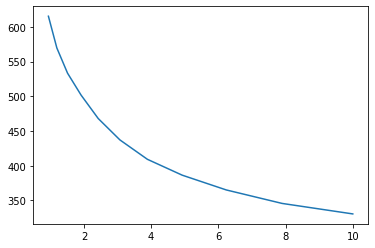

In [60]:
print(masses[0])
fig, ax = plt.subplots()

pos = np.where((ages>0.9) & (ages<10.5))

ax.plot(ages[pos], np.array(Teff[masses[0]])[pos])

In [24]:
i = 36
age  = ages[i]
mass = masses[4]
print(age, mass)

4.92388263 0.019


In [25]:
print(derivativeTint_wrt_A(mass, age, points, values, size=7000, h=0.001))
print((Teff[mass][i+1] - Teff[mass][i-1])/(ages[i+1]-ages[i-1]))

-22.676885676929714
-25.16529535985771


In [78]:
print(derivativeTint_wrt_A(mass, age, points, values, size=7000, h=0.001))
print((Teff[mass][i+1] - Teff[mass][i-1])/(ages[i+1]-ages[i-1]))

-287.04164558348566
-264.3043419520106


**Checking derivative of TDM wrt M**

In [91]:
from utils import T_DM
import astropy.units as u
from astropy.constants import M_jup, M_sun

In [98]:
print(masses)

masses_inkg = np.array(masses)*M_sun.value
print(masses_inkg)

[0.015 0.016 0.017 0.018 0.019 0.02  0.021 0.022 0.023 0.024 0.025 0.026
 0.027 0.028 0.029 0.03  0.031 0.032 0.033 0.034 0.035 0.036 0.037 0.038
 0.039 0.04  0.041 0.042 0.043 0.044 0.045 0.046 0.047 0.048 0.049 0.05
 0.051]
[2.98261481e+28 3.18145579e+28 3.38029678e+28 3.57913777e+28
 3.77797875e+28 3.97681974e+28 4.17566073e+28 4.37450172e+28
 4.57334270e+28 4.77218369e+28 4.97102468e+28 5.16986566e+28
 5.36870665e+28 5.56754764e+28 5.76638863e+28 5.96522961e+28
 6.16407060e+28 6.36291159e+28 6.56175257e+28 6.76059356e+28
 6.95943455e+28 7.15827553e+28 7.35711652e+28 7.55595751e+28
 7.75479850e+28 7.95363948e+28 8.15248047e+28 8.35132146e+28
 8.55016244e+28 8.74900343e+28 8.94784442e+28 9.14668541e+28
 9.34552639e+28 9.54436738e+28 9.74320837e+28 9.94204935e+28
 1.01408903e+29]


In [126]:
r = 0.1

TDM = []

for mass in masses_inkg:
    TDM.append(T_DM(r, M=mass, f=0.2, params=[0.1, 20., 0.42], v=100.))

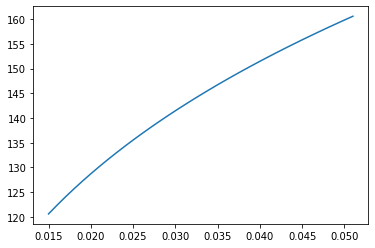

In [127]:
fig, ax = plt.subplots()
ax.plot(masses, TDM)

In [128]:
i = 30
mass = masses[i]
print(mass)

0.045


In [129]:
print(derivativeTDM_wrt_M(r, 0.1, [0.2, 20., 0.42], mass, v=100.))
epsilon=0.001
print(0.5*(TDM[i+1]-TDM[i-1])/epsilon)

774.880027426605
832.5087626136849


**Checking derivative of TDM wrt r**

In [144]:
r = np.linspace(0.1, 1, 1000)

i = 30
mass = masses[i]

TDM1 = []
TDM2 = []

for i in range(len(r)):
    TDM1.append(T_DM(r[i], M=mass, f=1., params=[1., 20., 0.42], v=100.))
    TDM2.append(T_DM(r[i], M=mass, f=0.1, params=[0.2, 20., 0.42], v=100.))

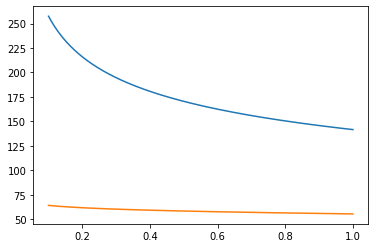

In [145]:
fig, ax = plt.subplots()
ax.plot(r, TDM1)
ax.plot(r, TDM2)

In [147]:
i = 970
print(derivativeTDM_wrt_r(r[i], 1., [1., 20., 0.42], mass, v=100.))
print((TDM1[i+1]-TDM1[i-1])/(r[i+1]-r[i-1]))

print(derivativeTDM_wrt_r(r[i], 0.1, [0.2, 20., 0.42], mass, v=100.))
print((TDM2[i+1]-TDM2[i-1])/(r[i+1]-r[i-1]))

-90.43268900962775
-40.02490811390011
-10.644012706958636
-4.71096853644078


In [159]:
from scipy.misc import derivative
conv_Msun_to_kg = 1.98841e+30

def derivando(r):    
    # return
    return (T_DM(r, M=mass*conv_Msun_to_kg, f=1., params=[1., 20., 0.42], v=100.))

In [161]:
derivative(derivando, r[i], dx=0.001)

-90.43273125442397

### Building analytical function for ATMO 2020 model

In [3]:
import bokeh.palettes
from scipy.optimize import curve_fit

In [4]:
path   = "../data/evolution_models/ATMO_2020_models/evolutionary_tracks/"
models = ["ATMO_CEQ/", "ATMO_NEQ_strong/", "ATMO_NEQ_weak/"]

evolution_ATMO20      = {}
evolution_ATMO20["M"] = []
for model in models:
    evolution_ATMO20[model] = {}
    files = glob.glob(path + model + "*.txt")
    for file in files:
        data = np.genfromtxt(file, unpack=True)
        evolution_ATMO20[model][data[0][0]] = [data[1], data[2], data[3], data[4], data[5]] 
        # age [Gyr] / Teff [K] / L [L/Lsun] / R [R/Rsun] / log g [cm/s2]
        if model==models[0]:
            #print (data[0][0], file)
            evolution_ATMO20["M"].append(data[0][0])

In [32]:
masses = np.sort(np.asarray(evolution_ATMO20["M"]))
pos    = np.where((masses > 0.004) & (masses < 0.073))
masses = masses[pos]
#print(masses)

ages = evolution_ATMO20["ATMO_CEQ/"][masses[0]][0]
Teff  = {}

for i in range(len(ages)):
    Teff[ages[i]] = []
    for mass in masses:
        Teff[ages[i]].append(evolution_ATMO20["ATMO_CEQ/"][mass][1][i])

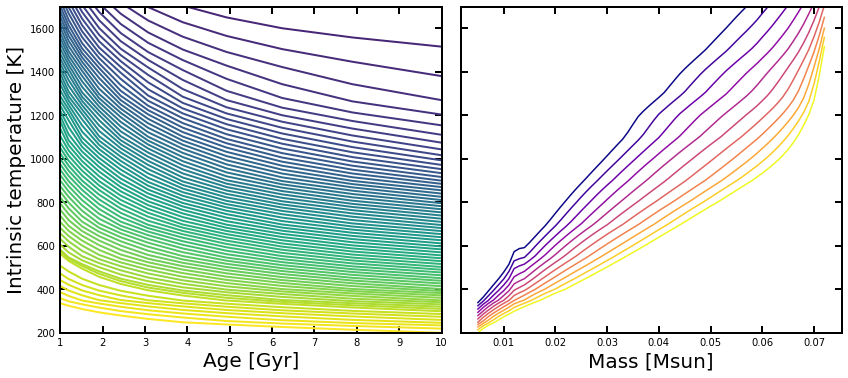

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

i     = 0
ls    = ["-", "--", ":"]
color = bokeh.palettes.viridis(len(evolution_ATMO20["M"]))
color = color[::-1]

models = ["ATMO_CEQ/"]#, "ATMO_NEQ_strong/", "ATMO_NEQ_weak/"]
for model in models:
    j = 0
    for mass in masses:
        #if (np.abs(mass-0.06) < 0.009) or (np.abs(mass-0.07) < 0.009):
        #    print(mass)
        #    continue
        ax[0].plot(evolution_ATMO20[model][mass][0], evolution_ATMO20[model][mass][1], 
                ls=ls[i], color=color[j], lw=2.)
        j = j+1
    i = i+1
ax[0].set_xlabel("Age [Gyr]", fontsize=20)
#ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlim([1, 10]); ax[0].set_ylim([200, 1700])
ax[0].set_ylabel(r"Intrinsic temperature [K]", fontsize=20) 


pos  = np.where((ages > 0.9) & (ages < 10.5))
ages = ages[pos]

color = bokeh.palettes.plasma(len(ages))
i=0

for age in ages:
    ax[1].plot(masses, Teff[age], color=color[i])
    i+=1        
ax[1].set_xlabel("Mass [Msun]", fontsize=20)

for axis in ['top','bottom','left','right']:
        ax[0].spines[axis].set_linewidth(2.); ax[1].spines[axis].set_linewidth(2.)
        
ax[0].tick_params(which='major',direction="in",width=2.,length=7,right=True,top=True,pad=5)
ax[1].tick_params(which='major',direction="in",width=2.,length=7,right=True,top=True,pad=5)

fig.subplots_adjust(wspace=0.05)

In [34]:
masses

array([0.005, 0.006, 0.007, 0.008, 0.009, 0.01 , 0.011, 0.012, 0.013,
       0.014, 0.015, 0.016, 0.017, 0.018, 0.019, 0.02 , 0.021, 0.022,
       0.023, 0.024, 0.025, 0.026, 0.027, 0.028, 0.029, 0.03 , 0.031,
       0.032, 0.033, 0.034, 0.035, 0.036, 0.037, 0.038, 0.039, 0.04 ,
       0.041, 0.042, 0.043, 0.044, 0.045, 0.046, 0.047, 0.048, 0.049,
       0.05 , 0.051, 0.052, 0.053, 0.054, 0.055, 0.056, 0.057, 0.058,
       0.059, 0.06 , 0.061, 0.062, 0.063, 0.064, 0.065, 0.066, 0.067,
       0.068, 0.069, 0.07 , 0.071, 0.072])

Text(0, 0.5, 'Intrinsic temperature [K]')

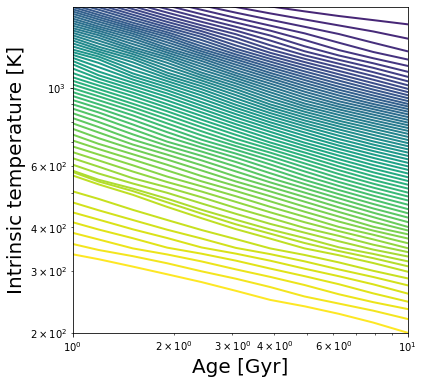

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6), sharey=True)

i     = 0
ls    = ["-", "--", ":"]
color = bokeh.palettes.viridis(len(evolution_ATMO20["M"]))
color = color[::-1]

models = ["ATMO_CEQ/"]#, "ATMO_NEQ_strong/", "ATMO_NEQ_weak/"]
for model in models:
    j = 0
    for mass in masses:
        #if (np.abs(mass-0.06) < 0.009) or (np.abs(mass-0.07) < 0.009):
        #    print(mass)
        #    continue
        ax.plot(evolution_ATMO20[model][mass][0], evolution_ATMO20[model][mass][1], 
                ls=ls[i], color=color[j], lw=2.)
        j = j+1
    i = i+1
ax.set_xlabel("Age [Gyr]", fontsize=20)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim([1, 10]); ax.set_ylim([200, 1700])
ax.set_ylabel(r"Intrinsic temperature [K]", fontsize=20) 

In [36]:
def objective_Tint_vs_age(age, a, b):
    return a*np.power(age, -b)

In [37]:
a = np.ones(len(masses))
b = np.ones(len(masses))
for i in range(len(masses)):
    ages  = evolution_ATMO20[model][masses[i]][0]
    temps = evolution_ATMO20[model][masses[i]][1]
    pos = np.where((ages>0.9) & (ages<10.1))
    
    # fit curve
    pars, cov = curve_fit(objective_Tint_vs_age, ages[pos], temps[pos])

    # cov - the estimated covariance of pars which can be used to determine the standard deviations of 
    #       the fitting parameters (square roots of the diagonals)
    _a, _b = pars
    a[i] = _a; b[i] = _b

In [12]:
#print(a, b, np.sqrt(cov[0, 0]), np.sqrt(cov[1, 1]))
#print(np.sqrt(cov[0, 0])/a*100, np.sqrt(cov[1, 1])/b*100)

/home/mariacst/exoplanets/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  


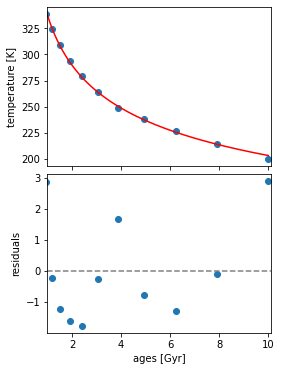

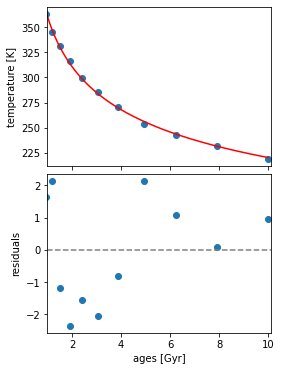

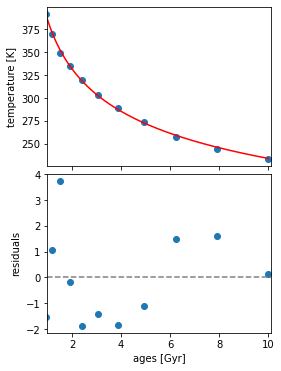

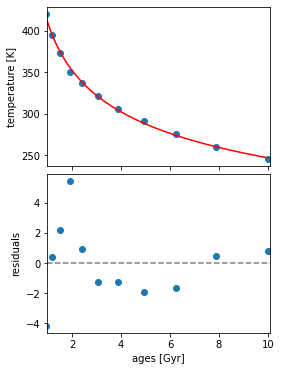

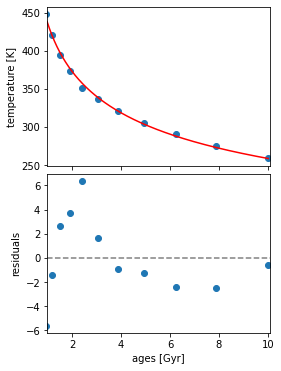

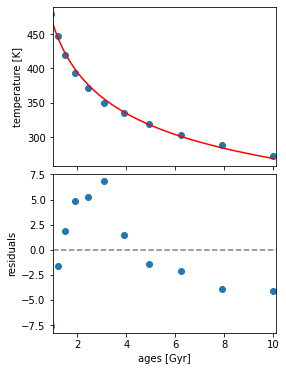

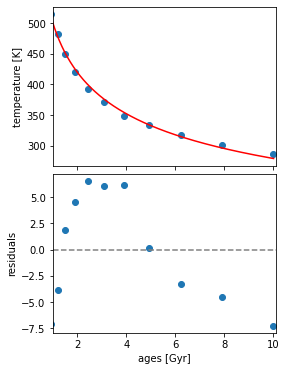

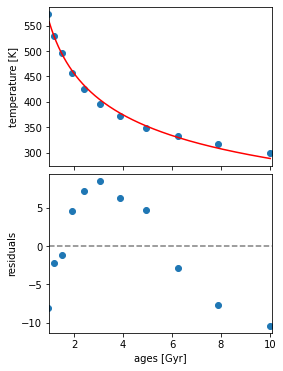

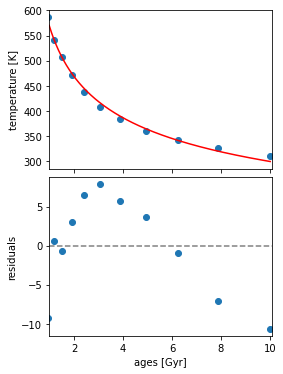

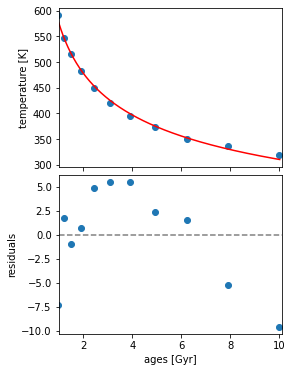

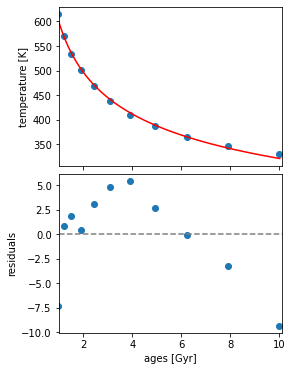

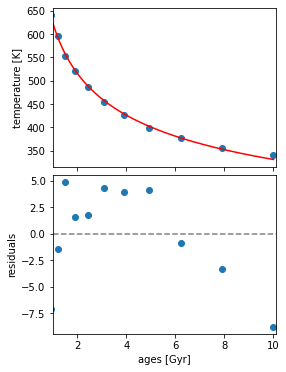

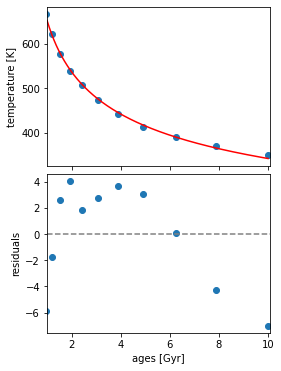

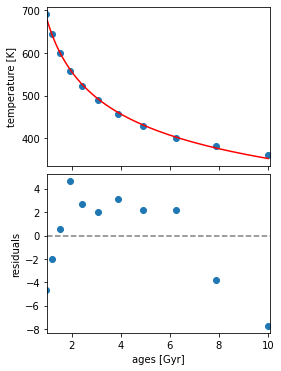

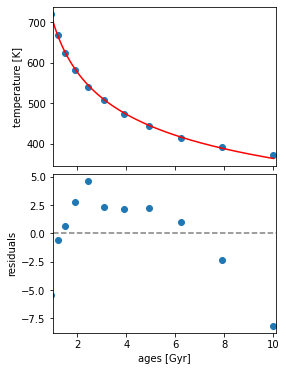

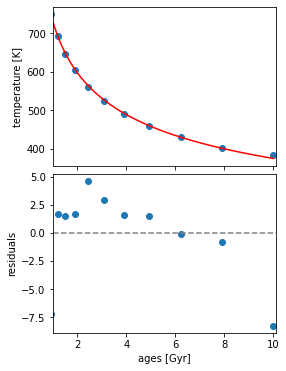

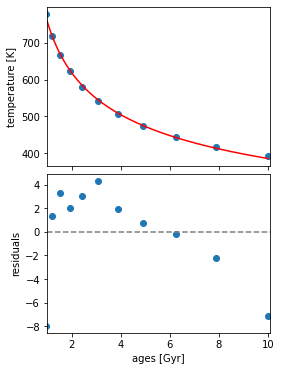

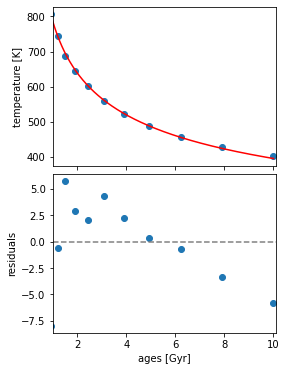

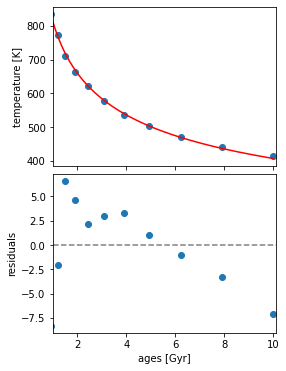

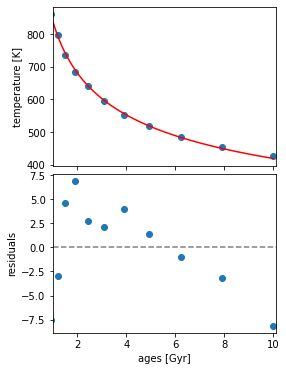

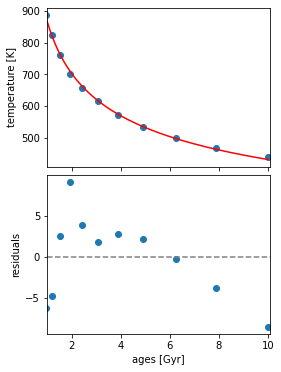

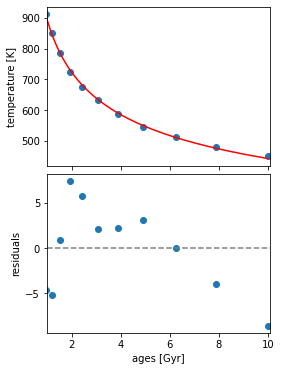

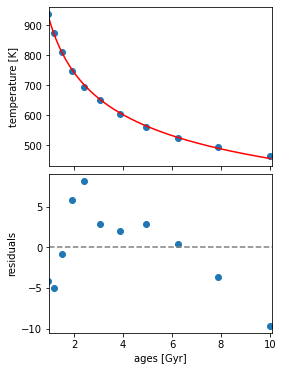

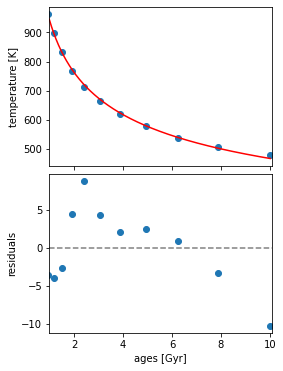

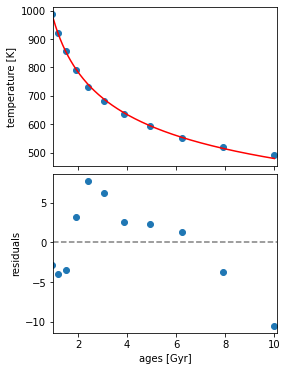

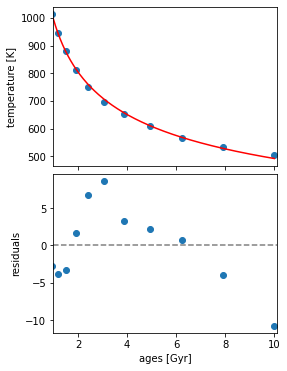

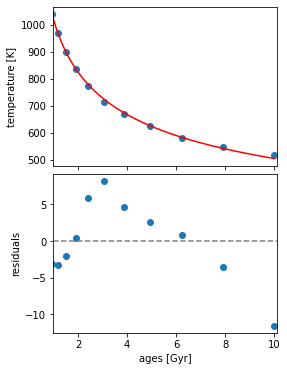

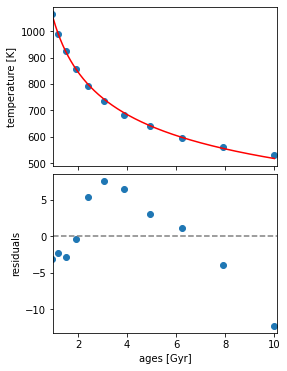

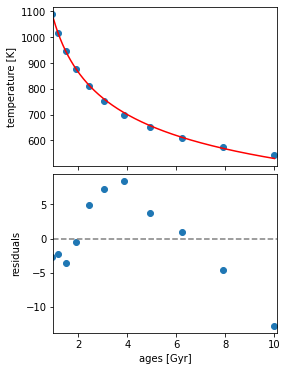

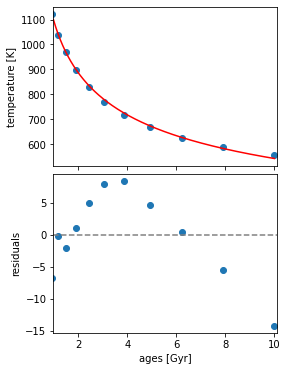

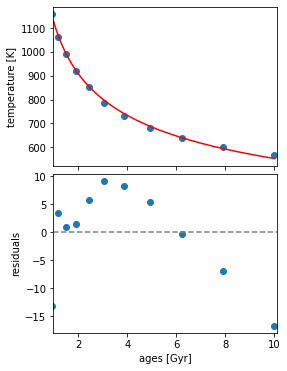

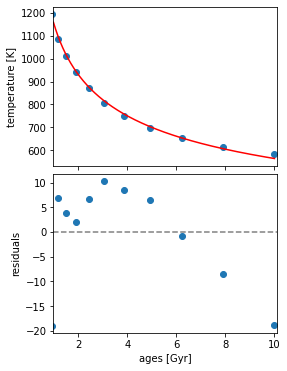

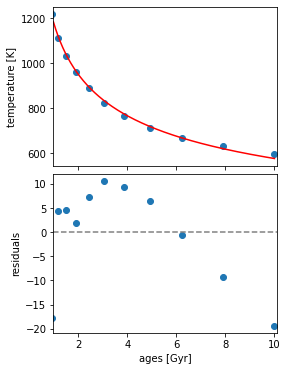

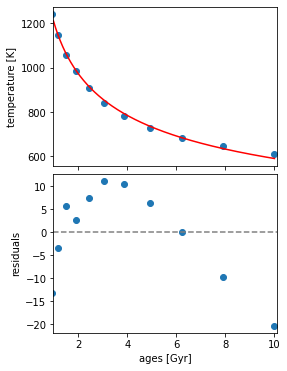

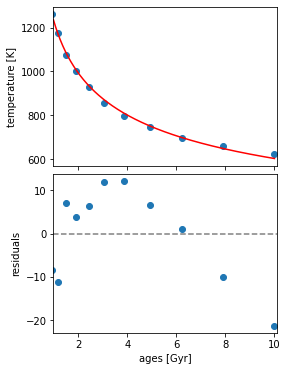

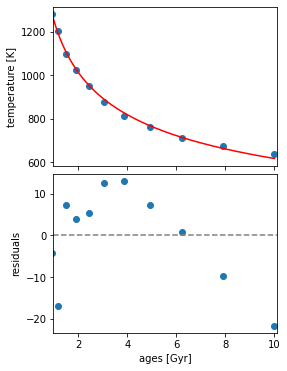

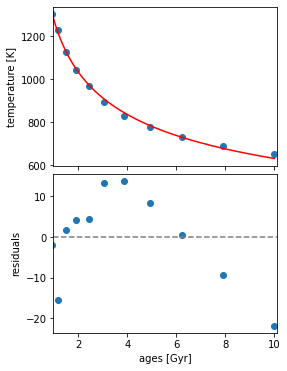

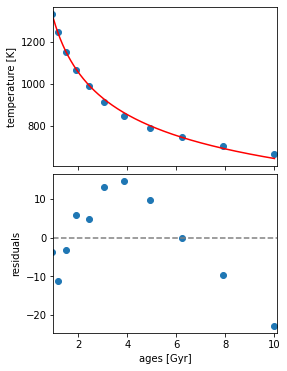

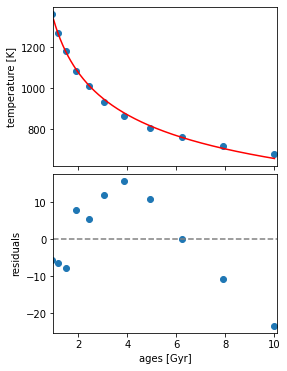

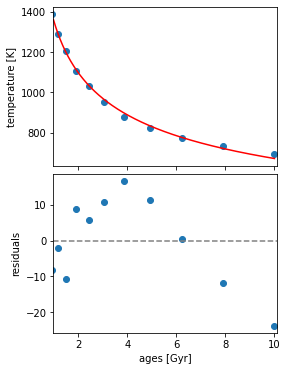

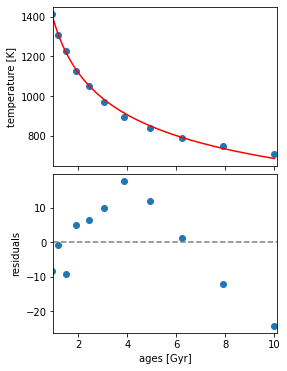

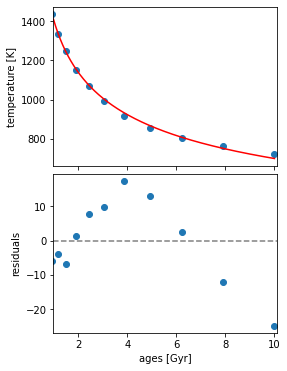

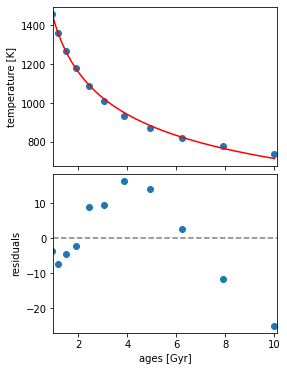

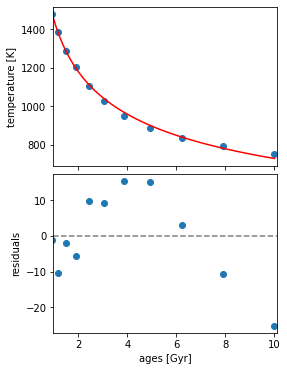

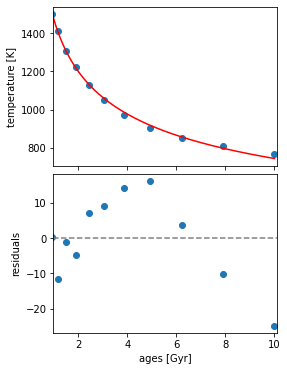

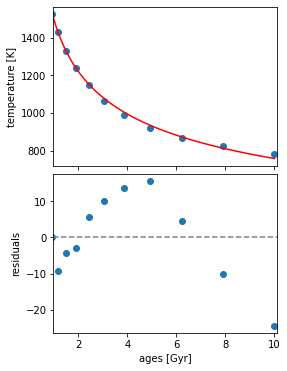

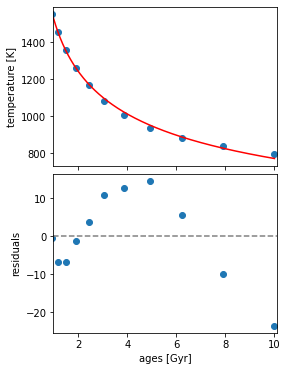

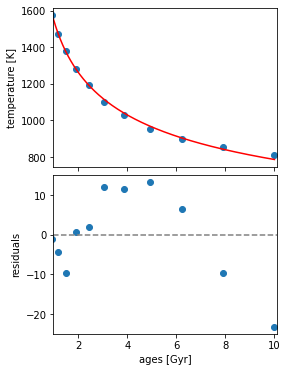

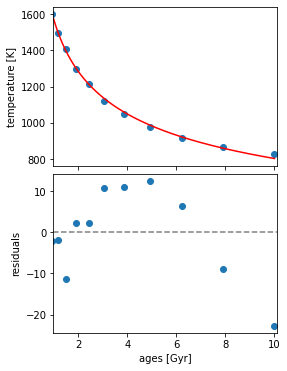

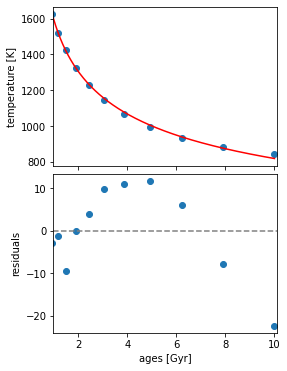

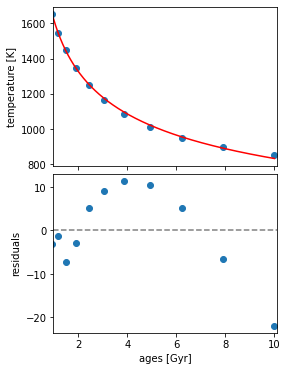

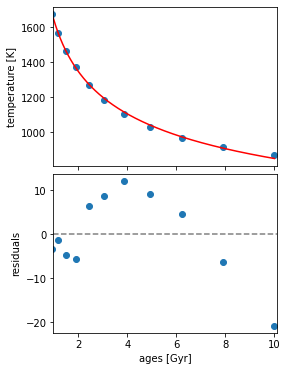

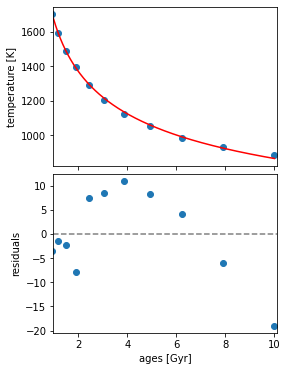

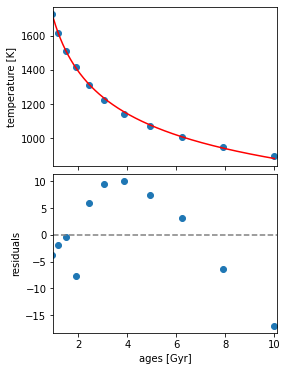

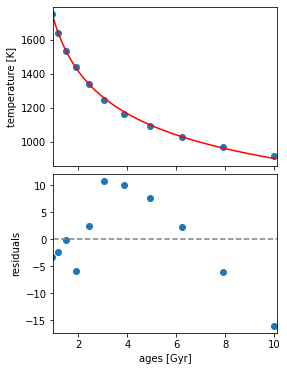

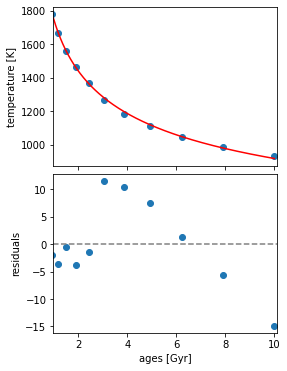

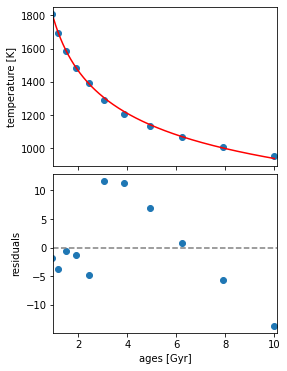

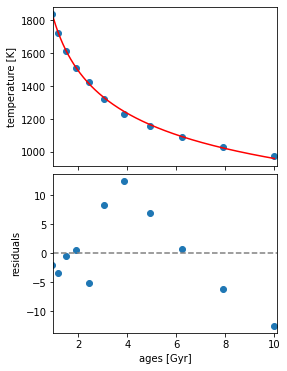

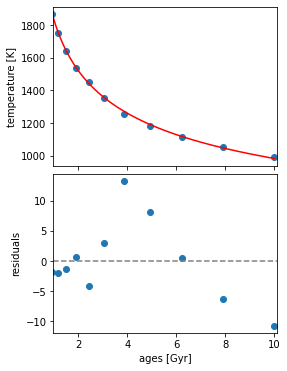

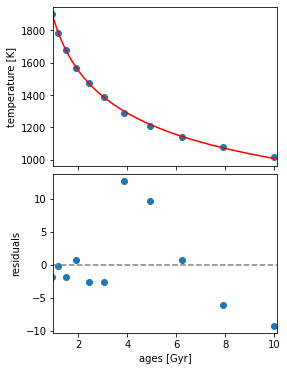

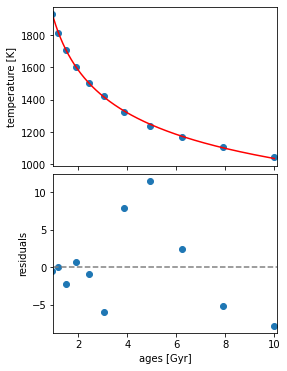

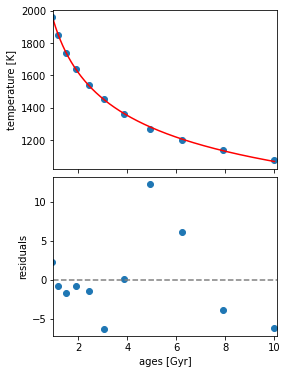

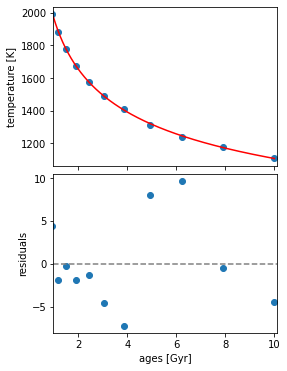

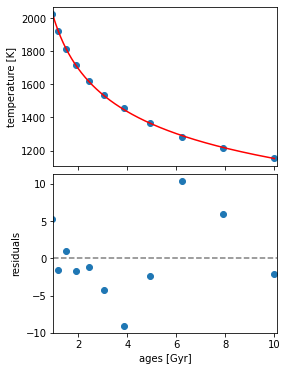

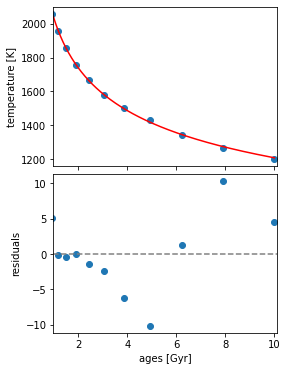

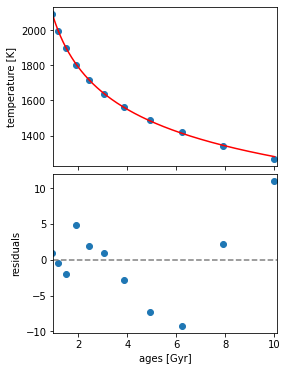

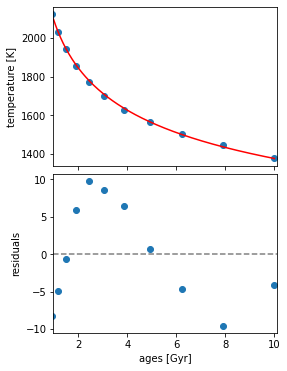

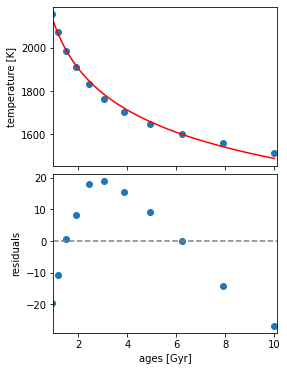

In [38]:
for i in range(len(masses)):
    fig, ax = plt.subplots(2, 1, sharex=True, figsize=(4, 6))
    
    ages  = evolution_ATMO20[model][masses[i]][0]
    temps = evolution_ATMO20[model][masses[i]][1]
    pos = np.where((ages>0.9) & (ages<10.1))
    
    ax[0].scatter(ages[pos], temps[pos])
    ax[0].plot(np.linspace(0.99, 10.01, 500), objective_Tint_vs_age(np.linspace(0.99, 10.01, 500), a[i], b[i]), color="r", ls="-")
    ax[0].set_ylabel("temperature [K]")
    ax[1].scatter(ages[pos], objective_Tint_vs_age(ages[pos], a[i], b[i]) - temps[pos])
    ax[1].set_ylabel("residuals"); ax[1].set_xlabel("ages [Gyr]")
    ax[1].axhline(0., color="grey", ls="--")

    ax[0].set_xlim(0.99, 10.1)

    fig.subplots_adjust(hspace=0.05)

In [39]:
from scipy.interpolate import interp1d
a_interp = interp1d(masses, a)
b_interp = interp1d(masses, b)

In [40]:
print(np.min(masses), np.max(masses))

0.005 0.072


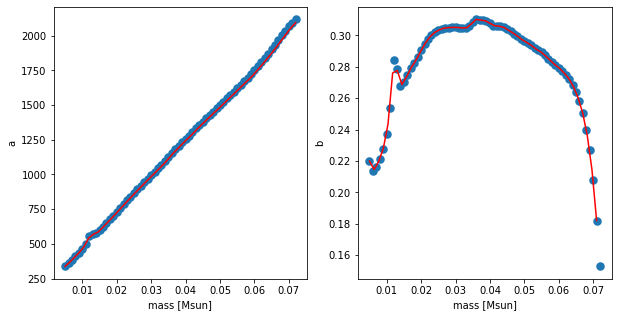

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(masses, a, lw=2.5); ax[0].set_ylabel("a"); ax[0].set_xlabel("mass [Msun]")
ax[0].plot(np.linspace(0.005, 0.072), a_interp(np.linspace(0.005, 0.071)), color="r")
ax[1].scatter(masses, b, lw=2.5); ax[1].set_ylabel("b"); ax[1].set_xlabel("mass [Msun]")
ax[1].plot(np.linspace(0.005, 0.071), b_interp(np.linspace(0.005, 0.071)), color="r")

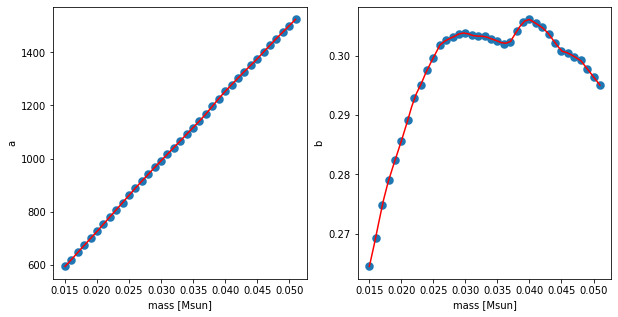

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(masses, a, lw=2.5); ax[0].set_ylabel("a"); ax[0].set_xlabel("mass [Msun]")
ax[0].plot(np.linspace(0.015, 0.051), a_interp(np.linspace(0.015, 0.051)), color="r")
ax[1].scatter(masses, b, lw=2.5); ax[1].set_ylabel("b"); ax[1].set_xlabel("mass [Msun]")
ax[1].plot(np.linspace(0.015, 0.051), b_interp(np.linspace(0.015, 0.051)), color="r")

**Finding analytical function for the derivatives of a & b with respect to the mass**

**a**

In [55]:
# first method

def objective_a_vs_mass(mass, a1, a2):
    return a1*mass + a2

pars, cov = curve_fit(objective_a_vs_mass, masses, a)
a1, a2 = pars
print(a1)

26019.238421829454


In [56]:
masses

array([0.005, 0.006, 0.007, 0.008, 0.009, 0.01 , 0.011, 0.012, 0.013,
       0.014, 0.015, 0.016, 0.017, 0.018, 0.019, 0.02 , 0.021, 0.022,
       0.023, 0.024, 0.025, 0.026, 0.027, 0.028, 0.029, 0.03 , 0.031,
       0.032, 0.033, 0.034, 0.035, 0.036, 0.037, 0.038, 0.039, 0.04 ,
       0.041, 0.042, 0.043, 0.044, 0.045, 0.046, 0.047, 0.048, 0.049,
       0.05 , 0.051, 0.052, 0.053, 0.054, 0.055, 0.056, 0.057, 0.058,
       0.059, 0.06 , 0.061, 0.062, 0.063, 0.064, 0.065, 0.066, 0.067,
       0.068, 0.069, 0.07 , 0.071, 0.072])

In [57]:
# second method

from scipy.misc import derivative
_a1 = []; _m_a1 = []
for i in range(len(masses)-3):
    _a1.append(derivative(interp1d(masses, a), masses[i+2], dx=1e-6))
    _m_a1.append(masses[i+2])

Text(0.5, 0, 'masses')

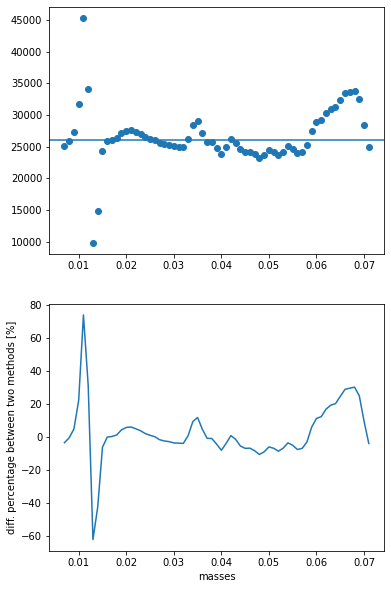

In [58]:
# comparison
fig, ax = plt.subplots(2, 1, figsize=(6, 10))
ax[0].scatter(_m_a1, _a1); ax[0].axhline(a1)
ax[1].plot(_m_a1, (np.array(_a1)-a1)/a1*100)
ax[1].set_ylabel("diff. percentage between two methods [%]"); ax[1].set_xlabel("masses")

**b**

In [59]:
from scipy.misc import derivative
_b1 = []; _m = []
for i in range(len(masses)-2):
    _b1.append(derivative(interp1d(masses, b), masses[i+1], dx=1e-6))
    _m.append(masses[i+1])

66 68


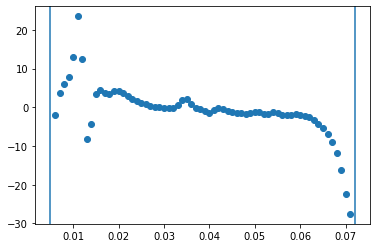

In [60]:
fig, ax = plt.subplots()

ax.axvline(masses[0]); ax.axvline(masses[-1])
ax.scatter(_m, _b1)
print(len(_m), len(masses))

In [61]:
print(_b1, len(_b1))

[-2.025832510701986, 3.7803110967682407, 5.938550925108088, 7.883005382722241, 12.940345421597055, 23.514110693345636, 12.454906527820109, -8.29164113980152, -4.19803012821629, 3.5264181368066527, 4.46112616386829, 3.788526338643905, 3.490842533288019, 4.082317563047777, 4.08763173234683, 3.699667886269964, 2.906655421797133, 2.1072345599282283, 1.5849599095674183, 1.1528319084908034, 0.8272385065843935, 0.33229026999426203, 0.1266398952648462, 0.11619189363432092, -0.07937662879764495, -0.24329300510328444, -0.20033232434046866, 0.578370096343539, 1.8578475250718984, 2.166497079653107, 0.8212568990417779, -0.3063747845422071, -0.39220614392321274, -0.926949032808988, -1.4813386058631917, -0.8118043363092298, -0.17205447425117093, -0.4949312059909783, -1.0010584822195412, -1.2910306699809304, -1.3659104025898205, -1.5081638727321156, -1.6791985969766277, -1.575516927643239, -1.2767498726029558, -1.3340242848713935, -1.6688705258560699, -1.6236053887730417, -1.3206345740868208, -1.57852

In [62]:
_b1.insert(0, _b1[0])
_b1.append(_b1[-1])

In [63]:
print(_b1, len(_b1))

[-2.025832510701986, -2.025832510701986, 3.7803110967682407, 5.938550925108088, 7.883005382722241, 12.940345421597055, 23.514110693345636, 12.454906527820109, -8.29164113980152, -4.19803012821629, 3.5264181368066527, 4.46112616386829, 3.788526338643905, 3.490842533288019, 4.082317563047777, 4.08763173234683, 3.699667886269964, 2.906655421797133, 2.1072345599282283, 1.5849599095674183, 1.1528319084908034, 0.8272385065843935, 0.33229026999426203, 0.1266398952648462, 0.11619189363432092, -0.07937662879764495, -0.24329300510328444, -0.20033232434046866, 0.578370096343539, 1.8578475250718984, 2.166497079653107, 0.8212568990417779, -0.3063747845422071, -0.39220614392321274, -0.926949032808988, -1.4813386058631917, -0.8118043363092298, -0.17205447425117093, -0.4949312059909783, -1.0010584822195412, -1.2910306699809304, -1.3659104025898205, -1.5081638727321156, -1.6791985969766277, -1.575516927643239, -1.2767498726029558, -1.3340242848713935, -1.6688705258560699, -1.6236053887730417, -1.320634

In [64]:
# Save b1 array
_b1 = np.array(_b1)

print(_b1.shape, type(_b1))

np.savetxt("dderv_ana_wrt_AM.dat", np.array([masses, _b1]).T, fmt="%.6f  %.6f")

(68,) <class 'numpy.ndarray'>


**Derivative Tint wrt mass**

In [65]:
def objective_Tint_vs_mass(mass, c, d):
    return c*mass + d

In [66]:
pos = np.where((ages>0.90))
print(ages[pos])

[ 0.94266845  1.19377664  1.51177507  1.91448198  2.42446202  3.07029063
  3.88815518  4.92388263  6.23550734  7.89652287 10.        ]


In [67]:
c = np.ones(len(ages[pos]))
d = np.ones(len(ages[pos]))
for i in range(len(ages[pos])):    
    # fit curve
    pars, cov = curve_fit(objective_Tint_vs_mass, masses, Teff[ages[pos][i]])

    # cov - the estimated covariance of pars which can be used to determine the standard deviations of 
    #       the fitting parameters (square roots of the diagonals)
    _c, _d = pars
    c[i] = _c; d[i] = _d

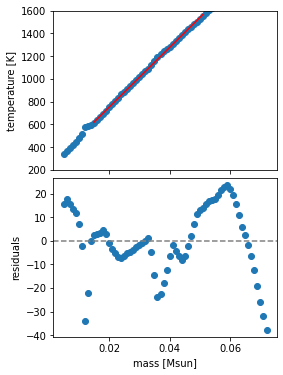

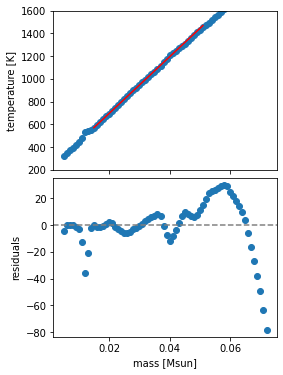

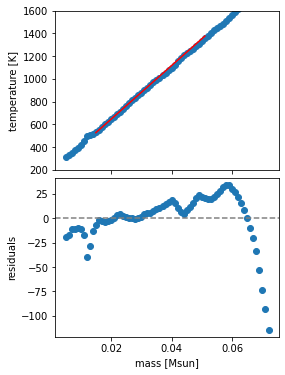

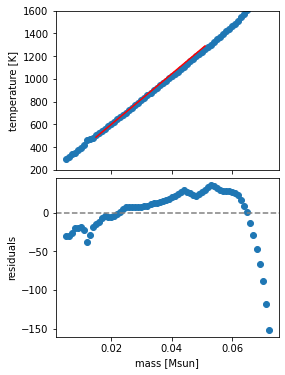

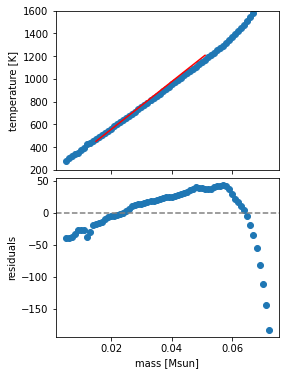

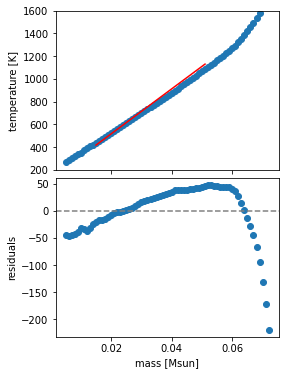

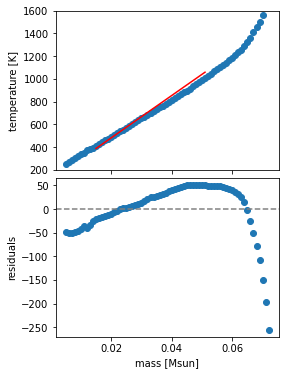

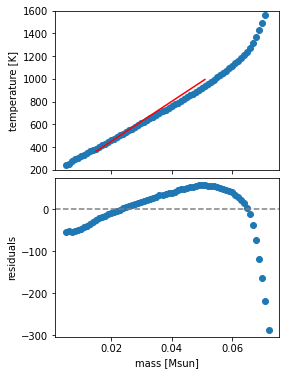

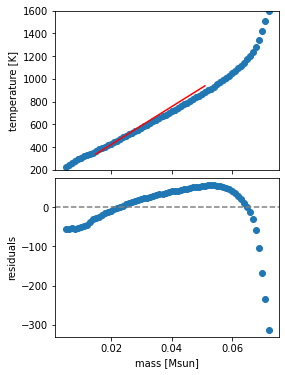

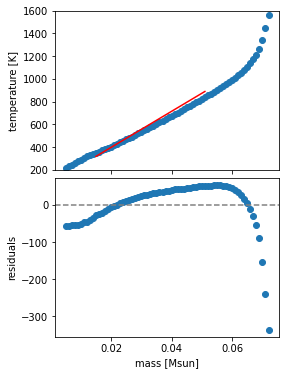

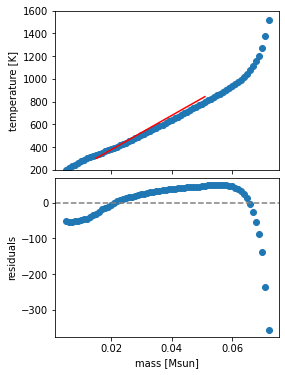

In [68]:
for i in range(len(ages[pos])):
    fig, ax = plt.subplots(2, 1, sharex=True, figsize=(4, 6))
    
    ax[0].scatter(masses, Teff[ages[pos][i]])
    ax[0].plot(np.linspace(0.015, 0.051, 500), objective_Tint_vs_mass(np.linspace(0.015, 0.051, 500), c[i], d[i]), color="r", ls="-")
    ax[0].set_ylabel("temperature [K]")
    ax[1].scatter(masses, objective_Tint_vs_mass(masses, c[i], d[i]) - Teff[ages[pos][i]])
    ax[1].set_ylabel("residuals"); ax[1].set_xlabel("mass [Msun]")
    ax[1].axhline(0., color="grey", ls="--")

    ax[0].set_ylim(200, 1600)

    fig.subplots_adjust(hspace=0.05)

In [69]:
c_interp = interp1d(ages[pos], c)
d_interp = interp1d(ages[pos], d)

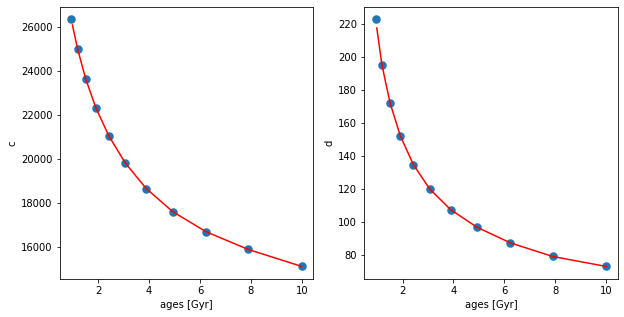

In [70]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(ages[pos], c, lw=2.5); ax[0].set_ylabel("c"); ax[0].set_xlabel("ages [Gyr]")
ax[0].plot(np.linspace(0.99, 10., 100), c_interp(np.linspace(0.99, 10., 100)), color="r")
ax[1].scatter(ages[pos], d, lw=2.5); ax[1].set_ylabel("d"); ax[1].set_xlabel("ages [Gyr]")
ax[1].plot(np.linspace(0.99, 10., 100), d_interp(np.linspace(0.99, 10., 100)), color="r")

**Finding analytical function for the derivatives of c with respect to the mass**

In [74]:
pos = np.where((ages>0.90))
print(len(ages[pos]), len(c))

print(ages[pos], ages)

11 11
[ 0.94266845  1.19377664  1.51177507  1.91448198  2.42446202  3.07029063
  3.88815518  4.92388263  6.23550734  7.89652287 10.        ] [1.00000000e-03 1.26638017e-03 1.60371874e-03 2.03091762e-03
 2.57191381e-03 3.25702066e-03 4.12462638e-03 5.22334507e-03
 6.61474064e-03 8.37677640e-03 1.06081836e-02 1.34339933e-02
 1.70125428e-02 2.15443469e-02 2.72833338e-02 3.45510729e-02
 4.37547938e-02 5.54102033e-02 7.01703829e-02 8.88623816e-02
 1.12533558e-01 1.42510267e-01 1.80472177e-01 2.28546386e-01
 2.89426612e-01 3.66524124e-01 4.64158883e-01 5.87801607e-01
 7.44380301e-01 9.42668455e-01 1.19377664e+00 1.51177507e+00
 1.91448198e+00 2.42446202e+00 3.07029063e+00 3.88815518e+00
 4.92388263e+00 6.23550734e+00 7.89652287e+00 1.00000000e+01]


In [80]:
from scipy.misc import derivative
_c1 = []; _a = np.linspace(0.943, 9.9, 20)
for i in range(len(_a)):
    _c1.append(derivative(interp1d(ages[pos], c), _a[i], dx=1e-6))

20 11


Text(0, 0.5, 'dc/dA [K/Msun/Gyr]')

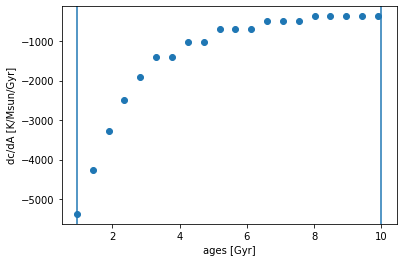

In [81]:
fig, ax = plt.subplots()

ax.axvline(ages[pos][0]); ax.axvline(ages[pos][-1])
ax.scatter(_a, _c1)
print(len(_a), len(ages[pos]))
ax.set_xlabel("ages [Gyr]"); ax.set_ylabel("dc/dA [K/Msun/Gyr]")

In [82]:
print(_c1, len(_c1))

[-5378.754593039048, -4265.78743281425, -3279.6358991618035, -2502.0590546773747, -1896.8149724969408, -1411.3600100245094, -1411.3600100245094, -1008.4286932396935, -1008.4286932396935, -697.7031680435175, -697.7031680435175, -697.7031680435175, -485.2323036175221, -485.2323036175221, -485.2323036175221, -366.99353859148687, -366.99353859148687, -366.99353859148687, -366.99353859148687, -366.99353859148687] 20


In [83]:
_c1.append(_c1[-1])
_a = _a.tolist()
_a.append(ages[-1])

In [84]:
print(_c1, len(_c1))
print(_a, len(_a))

[-5378.754593039048, -4265.78743281425, -3279.6358991618035, -2502.0590546773747, -1896.8149724969408, -1411.3600100245094, -1411.3600100245094, -1008.4286932396935, -1008.4286932396935, -697.7031680435175, -697.7031680435175, -697.7031680435175, -485.2323036175221, -485.2323036175221, -485.2323036175221, -366.99353859148687, -366.99353859148687, -366.99353859148687, -366.99353859148687, -366.99353859148687, -366.99353859148687] 21
[0.943, 1.414421052631579, 1.885842105263158, 2.357263157894737, 2.828684210526316, 3.300105263157895, 3.771526315789474, 4.242947368421053, 4.714368421052631, 5.18578947368421, 5.657210526315789, 6.128631578947369, 6.600052631578947, 7.071473684210526, 7.542894736842105, 8.014315789473685, 8.485736842105263, 8.957157894736842, 9.42857894736842, 9.9, 10.0] 21


In [85]:
# Save b1 array
_c1 = np.array(_c1); _a = np.array(_a)

print(_c1.shape, type(_c1), _a.shape, type(_a))

np.savetxt("dderv_ana_wrt_MA.dat", np.array([_a, _c1]).T, fmt="%.6f  %.6f")

(21,) <class 'numpy.ndarray'> (21,) <class 'numpy.ndarray'>


In [86]:
!tail dderv_ana_wrt_MA.dat

6.128632  -697.703168
6.600053  -485.232304
7.071474  -485.232304
7.542895  -485.232304
8.014316  -366.993539
8.485737  -366.993539
8.957158  -366.993539
9.428579  -366.993539
9.900000  -366.993539
10.000000  -366.993539


**Back to first derivatives**

In [46]:
# Save a, b, c arrays
print(a.shape, b.shape, c.shape, type(a), type(b), type(c))

np.savetxt("derv_ana_wrt_A.dat", np.array([masses, a, b]).T, fmt="%.6f  %.6f  %.6f")
np.savetxt("derv_ana_wrt_M.dat", np.array([ages[pos], c]).T, fmt="%.6f  %.6f")

In [39]:
# Load a, b, c arrays

masses, a, b = np.genfromtxt("derv_ana_wrt_A.dat", unpack=True)
ages, c = np.genfromtxt("derv_ana_wrt_M.dat", unpack=True)

In [15]:
derivativeTintana_wrt_M = interp1d(ages[pos], c) # [K/Msun]

In [16]:
def derivativeTintana_wrt_A(M, A, a, b):
    """
    Return (analytical) derivative of interinsic temperature wrt age [K/Gyr]
    (ATMO temperatures are fitted by a/A^b)
    
    Input
    -----
        M : mass [Msun]
        A : age [Gyr]
        a : =f(M) - interpolation function
        b : =f(M) - interpolation function
    """
    return (-a(M)*b(M)*np.power(A, -b(M)-1))

In [43]:
i = 4
age  = ages[i]
mass = masses[34]
print(age, mass)

# Load theoretical cooling model                                                   
path = "/home/mariacst/exoplanets/running/data/"                                   
data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)               
points = np.transpose(data[0:2, :])                                                
values = data[2] 

2.424462 0.049


In [44]:
print(derivativeTintana_wrt_A(mass, age, a_interp, b_interp))
print(derivativeTint_wrt_A(mass, age, points, values))
print("-------")
age=9.5
print(derivativeTintana_wrt_A(mass, age, a_interp, b_interp))
print(derivativeTint_wrt_A(mass, age, points, values))

-139.24979485380462
-164.39625339626218
-------
-23.661393870015818
-18.733516664838135


In [45]:
print(derivativeTintana_wrt_M(age))
print(derivativeTint_wrt_M(mass, age, points, values, size=7000, h=0.001))

13303.254013025344
14430.965563427264


In [56]:
print(derivativeTintana_wrt_A(mass, age, a_interp, b_interp))
print(derivativeTint_wrt_A(mass, age, points, values))
print("-------")
age=2.5
print(derivativeTintana_wrt_A(mass, age, a_interp, b_interp))
print(derivativeTint_wrt_A(mass, age, points, values))

-23.661387319449407
-18.733516664838135
-------
-133.81388653111316
-122.05031349685669


**Checking results of emcee**

In [2]:
import pickle
from _corner import corner
from scipy.stats import gaussian_kde, binned_statistic

0.5248751319324567 69.9996843907721    -0.6522327009677156 1.0
0.000725182440090899 2.5999392175524685    -3.3762197466376165 1.0
0.010047783846549141 1.999999208793445    -0.13157226551606982 1.0


Text(0.5, 0, '$\\gamma$')

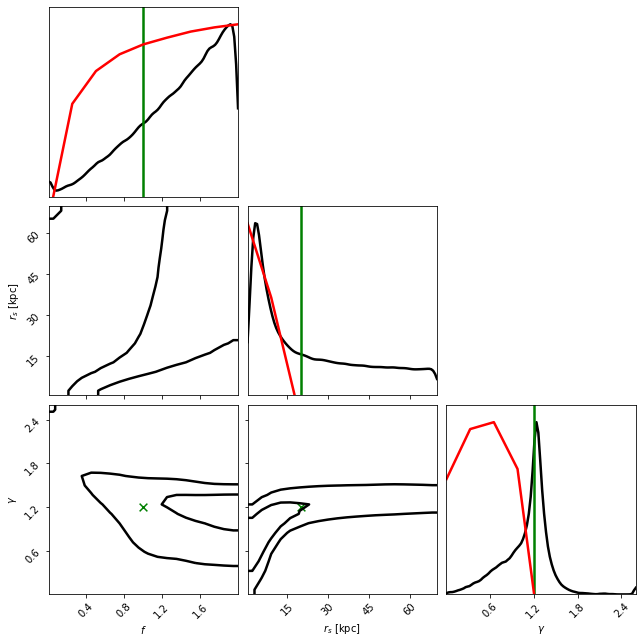

In [4]:
nBDs = 1000 ; sigma = 0.2; f = 1.; gamma = 1.2; rs = 20.

filepath = ("/home/mariacst/exoplanets/running/Tcut_ana/N%isigma%.1f/" %(nBDs, sigma))
_file    = open(filepath + ("posterior_test_N%i_sigma%.1f_f1.0gamma%.1frs%.1fv56" %(nBDs, sigma, gamma, rs)), "rb") 
samples  = pickle.load(_file)
_file    = open(filepath + ("like_test_N%i_sigma%.1f_f1.0gamma%.1frs%.1fv56" 
                            %(nBDs, sigma, gamma, rs)), "rb") 
like     = pickle.load(_file)

smooth=1.
fig, axes = corner(np.array([samples[:, 0], samples[:, 2], samples[:, 1]]).T, 
                   levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
                   plot_density=False, fill_contours=False, smooth=smooth, color="k")
# plot KDE smoothed version of distributions
for axidx, samps in zip([0, 4, 8], np.array([samples[:, 0], samples[:, 2], samples[:, 1]])):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim()
    xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="k", lw=2.5)      
    
axes[0, 0].axvline(1., color="g", ls="-", lw=2.5); axes[1, 1].axvline(rs, color="g", ls="-", lw=2.5); 
axes[2, 2].axvline(gamma, color="g", ls="-", lw=2.5); axes[2, 0].scatter(f, gamma, marker="x", color="g", s=60); 
axes[2, 1].scatter(rs, gamma, marker="x", color="g", s=60); 


bin_n=8
x = binned_statistic(samples[:, 2], like, 'max', bins=bin_n)[1] 
y = binned_statistic(samples[:, 2], like, 'max', bins=bin_n+1)[0]
y = y - np.max(y) + 1
print(np.min(x), np.max(x), "  ", np.min(y), np.max(y))
axes[1, 1].plot(x, y, ls="-", color="r", lw=2.5)

x = binned_statistic(samples[:, 1], like, 'max', bins=bin_n)[1] 
y = binned_statistic(samples[:, 1], like, 'max', bins=bin_n+1)[0]
y = y - np.max(y) + 1
print(np.min(x), np.max(x), "  ", np.min(y), np.max(y))
axes[2, 2].plot(x, y, ls="-", color="r", lw=2.5)

x = binned_statistic(samples[:, 0], like, 'max', bins=bin_n)[1] 
y = binned_statistic(samples[:, 0], like, 'max', bins=bin_n+1)[0]
y = y - np.max(y) + 1
print(np.min(x), np.max(x), "  ", np.min(y), np.max(y))
axes[0, 0].plot(x, y, ls="-", color="r", lw=2.5)

axes[1, 0].set_ylabel(r"$r_s$ [kpc]")
axes[2, 0].set_xlabel(r"$f$")
axes[2, 0].set_ylabel(r"$\gamma$")
axes[2, 1].set_xlabel(r"$r_s$ [kpc]")
axes[2, 2].set_xlabel(r"$\gamma$")